## Time Series EDA

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/creditcard.csv')

# Converting Time to actual Datetime
start_date = pd.Timestamp('2025-01-01')
df['Datetime'] = start_date + pd.to_timedelta(df['Time'], unit='s')
df['Hour'] = df['Datetime'].dt.hour
df['Minute'] = df['Datetime'].dt.minute
df['DayOfWeek'] = df['Datetime'].dt.dayofweek
df['TimeOfDay'] = df['Datetime'].dt.hour + df['Datetime'].dt.minute / 60

print("Dataset Shape:", df.shape)
print(f"\nTime Range: {df['Datetime'].min()} to {df['Datetime'].max()}")
print(f"Duration: {(df['Datetime'].max() - df['Datetime'].min()).total_seconds() / 3600:.2f} hours")
print(f"\nFraud Rate: {df['Class'].sum() / len(df) * 100:.4f}%")

Dataset Shape: (284807, 36)

Time Range: 2025-01-01 00:00:00 to 2025-01-02 23:59:52
Duration: 48.00 hours

Fraud Rate: 0.1727%


## Temporal Pattern Analysis

In [21]:
# Aggregate transactions by time windows
def create_time_series_features(df, window='10min'):
    """Create time-series aggregations"""
    
    df_sorted = df.sort_values('Datetime').copy()
    
    # Resample by time window
    ts_features = df_sorted.set_index('Datetime').resample(window).agg({
        'Amount': ['count', 'sum', 'mean', 'std', 'max'],
        'Class': ['sum', 'mean']
    }).reset_index()
    
    ts_features.columns = ['_'.join(col).strip('_') for col in ts_features.columns]
    ts_features.rename(columns={'Datetime': 'Datetime'}, inplace=True)
    
    return ts_features

# Create 10-minute windows
ts_10min = create_time_series_features(df, '10min')
print("="*60)
print("      Time-Series Features (10-min windows):")
print("="*60)
print(ts_10min.head())

# Visualize transaction volume and fraud over time
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=('Transaction Volume Over Time', 
                    'Fraud Count Over Time',
                    'Average Transaction Amount Over Time'),
    vertical_spacing=0.1
)

fig.add_trace(
    go.Scatter(x=ts_10min['Datetime'], y=ts_10min['Amount_count'],
               name='Transaction Count', line=dict(color='blue')),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=ts_10min['Datetime'], y=ts_10min['Class_sum'],
               name='Fraud Count', line=dict(color='red')),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=ts_10min['Datetime'], y=ts_10min['Amount_mean'],
               name='Avg Amount', line=dict(color='green')),
    row=3, col=1
)

fig.update_layout(height=900, showlegend=False, title_text="Time-Series Analysis")
fig.write_html('../images/timeseries_overview.html')
fig.show()

      Time-Series Features (10-min windows):
             Datetime  Amount_count  Amount_sum  Amount_mean  Amount_std  \
0 2025-01-01 00:00:00           788    54709.33    69.428084  197.544495   
1 2025-01-01 00:10:00           741    51610.22    69.649420  169.050117   
2 2025-01-01 00:20:00           731    49140.93    67.224254  334.438568   
3 2025-01-01 00:30:00           565    39964.90    70.734336  218.568846   
4 2025-01-01 00:40:00           685    31075.29    45.365387  108.311889   

   Amount_max  Class_sum  Class_mean  
0     3828.04          2    0.002538  
1     2452.03          0    0.000000  
2     7712.43          0    0.000000  
3     2909.97          0    0.000000  
4     1399.20          0    0.000000  


## User-Level Time-Series Features

In [ ]:
# Creating synthetic user sessions

# Create rolling window features for each transaction
def create_rolling_features(df, windows=[10, 50, 100]):
    """Create rolling/velocity features for time-series"""
    
    df_sorted = df.sort_values('Time').copy()
    
    for window in windows:
        # Transaction count in rolling window
        df_sorted[f'tx_count_{window}'] = df_sorted.groupby('Class')['Amount'].transform(
            lambda x: x.rolling(window, min_periods=1).count()
        )
        
        # Amount statistics in rolling window
        df_sorted[f'amount_mean_{window}'] = df_sorted.groupby('Class')['Amount'].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        
        df_sorted[f'amount_std_{window}'] = df_sorted.groupby('Class')['Amount'].transform(
            lambda x: x.rolling(window, min_periods=1).std()
        )
        
        df_sorted[f'amount_max_{window}'] = df_sorted.groupby('Class')['Amount'].transform(
            lambda x: x.rolling(window, min_periods=1).max()
        )
    
    return df_sorted

print("Creating rolling features...")
df_with_rolling = create_rolling_features(df, windows=[10, 50, 100])
print(df_with_rolling[['Time', 'Amount', 'Class', 'tx_count_10', 'amount_mean_10']].head(20))

Creating rolling features...
    Time  Amount  Class  tx_count_10  amount_mean_10
0    0.0  149.62      0          1.0      149.620000
1    0.0    2.69      0          2.0       76.155000
2    1.0  378.66      0          3.0      176.990000
3    1.0  123.50      0          4.0      163.617500
4    2.0   69.99      0          5.0      144.892000
5    2.0    3.67      0          6.0      121.355000
6    4.0    4.99      0          7.0      104.731429
7    7.0   40.80      0          8.0       96.740000
8    7.0   93.20      0          9.0       96.346667
9    9.0    3.68      0         10.0       87.080000
10  10.0    7.80      0         10.0       72.898000
11  10.0    9.99      0         10.0       73.628000
12  10.0  121.50      0         10.0       47.912000
13  11.0   27.50      0         10.0       38.312000
15  12.0   15.99      0         10.0       32.912000
16  12.0   12.99      0         10.0       33.844000
14  12.0   58.80      0         10.0       39.225000
17  13.0    0.89 

## Seasonal Decomposition

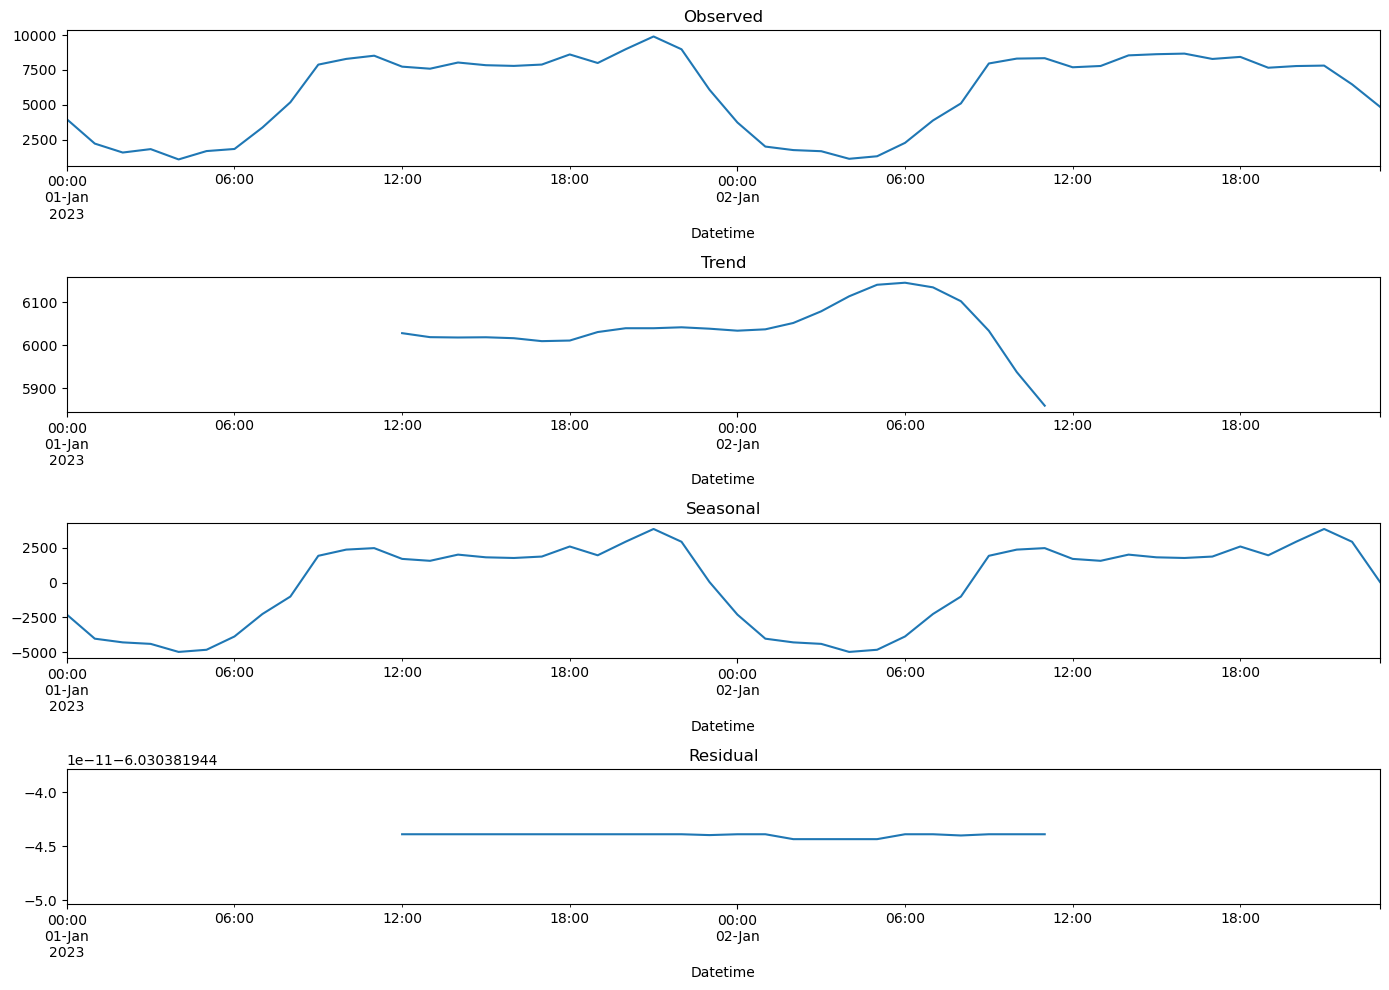

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Aggregate to hourly for decomposition
hourly_data = df.set_index('Datetime').resample('1H').agg({
    'Amount': 'count',
    'Class': 'sum'
}).rename(columns={'Amount': 'transaction_count', 'Class': 'fraud_count'})

# Fill missing hours with 0
hourly_data = hourly_data.fillna(0)

# Decompose transaction count
decomposition = seasonal_decompose(hourly_data['transaction_count'], 
                                   model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.savefig('../images/seasonal_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

## Anomaly in Time-Series Pattern

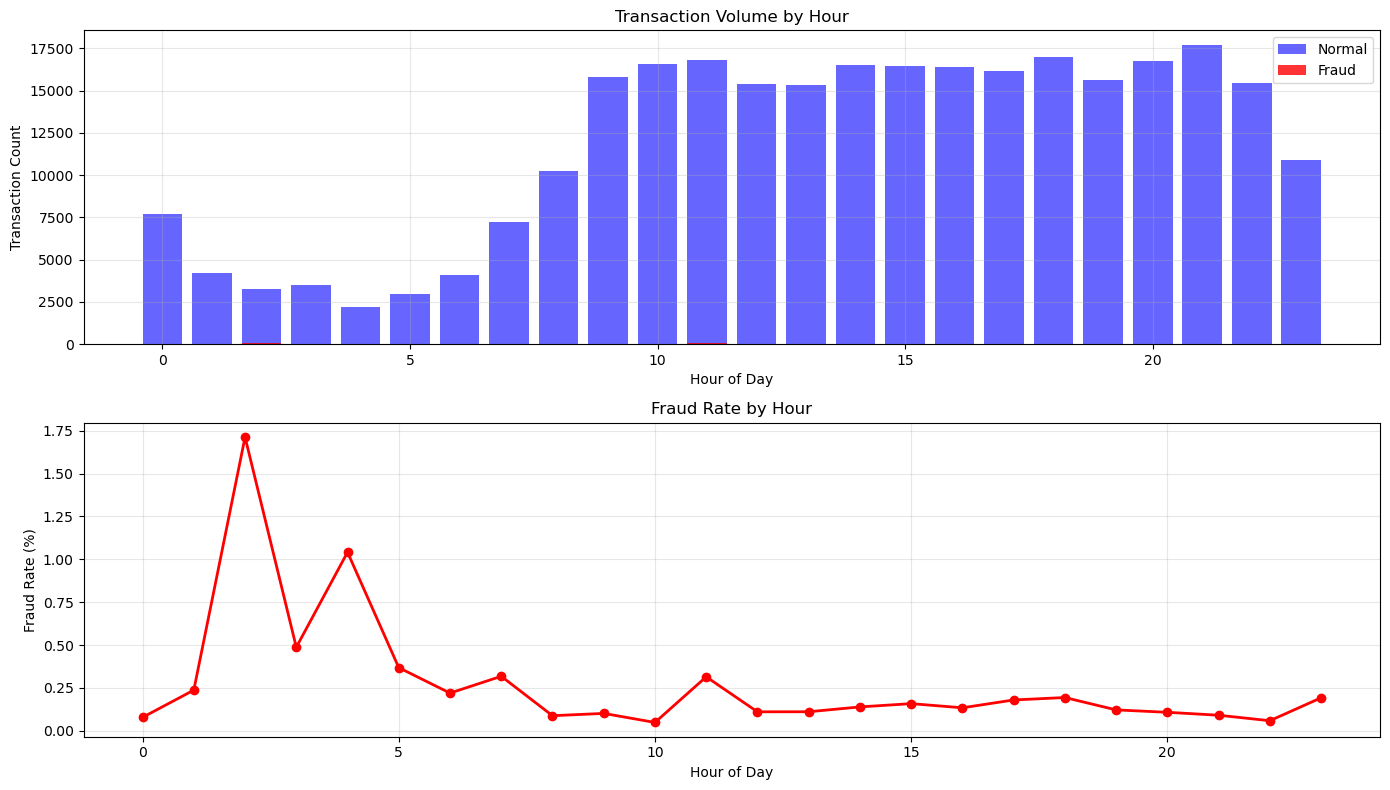


Fraud Rate by Hour:
Hour
2     1.712740
4     1.041195
3     0.486827
5     0.367893
7     0.317548
11    0.314428
1     0.236967
6     0.219459
18    0.193673
23    0.191991
17    0.179389
15    0.157949
14    0.138805
16    0.133714
19    0.121414
13    0.110641
12    0.110246
20    0.107424
9     0.101023
21    0.090380
8     0.087583
0     0.077973
22    0.058286
10    0.048199
Name: Class, dtype: float64


In [5]:
# Analyze fraud patterns vs normal patterns
fraud_by_hour = df[df['Class'] == 1].groupby('Hour').size()
normal_by_hour = df[df['Class'] == 0].groupby('Hour').size()

# Normalize to see rates
fraud_rate_by_hour = df.groupby('Hour')['Class'].mean() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Transaction counts
axes[0].bar(normal_by_hour.index, normal_by_hour.values, 
            alpha=0.6, label='Normal', color='blue')
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, 
            alpha=0.8, label='Fraud', color='red')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Transaction Volume by Hour')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fraud rate by hour
axes[1].plot(fraud_rate_by_hour.index, fraud_rate_by_hour.values, 
             marker='o', color='red', linewidth=2)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Hour')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/fraud_temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFraud Rate by Hour:")
print(fraud_rate_by_hour.sort_values(ascending=False))